## 1. Linear Regression

   YearsExperience  Salary
0              5.9   71445
1             14.3  146278
2             11.1  115797
3              9.2  102142
4              2.8   49391
Shape: (30, 2)
Null values:
 YearsExperience    0
Salary             0
dtype: int64
Predicted: [ 92547.11212639  56610.43955533  76076.13719799  93295.79280495
 101531.28026916 113510.17112618]
Actual   : [ 97058  56457  67585  93294 107713 110296]


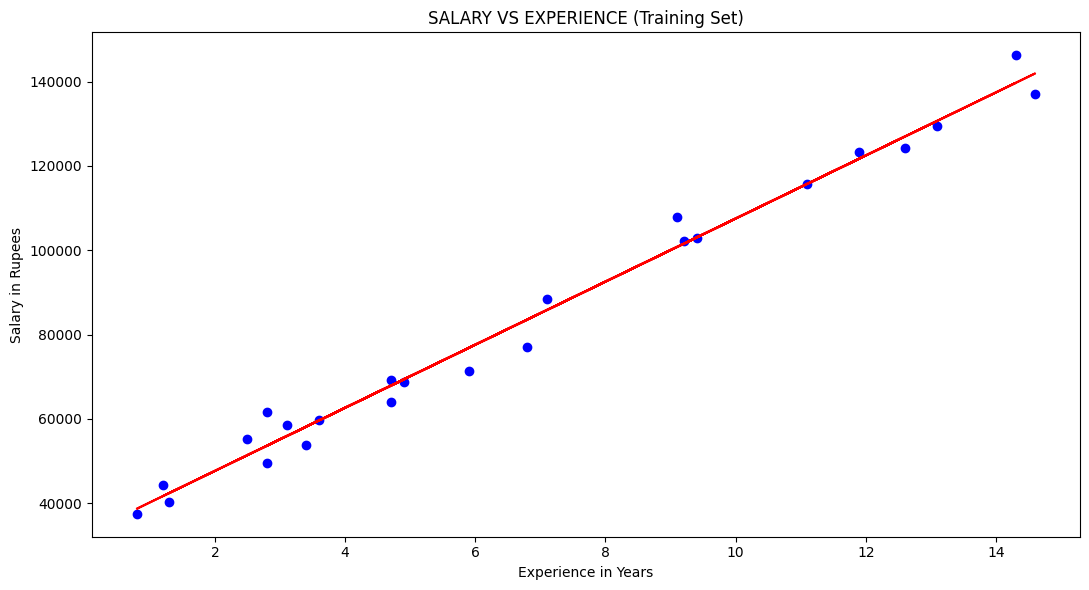

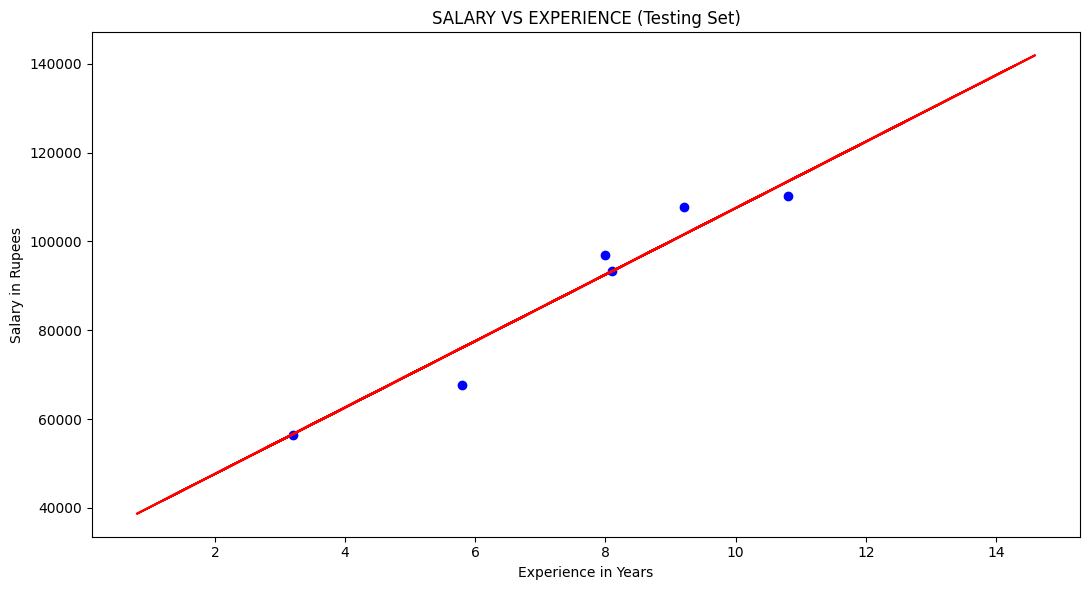

In [10]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
data = pd.read_csv('Salary_Data.csv')
print(data.head())
print("Shape:", data.shape)
print("Null values:\n", data.isnull().sum())

x = data.iloc[:, :1].values
y = data.iloc[:, 1:2].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print("Predicted:", y_pred.flatten())
print("Actual   :", y_test.flatten())

plt.scatter(x_train, y_train, color='blue')
plt.plot(x_train, model.predict(x_train), color='red')
plt.title('SALARY VS EXPERIENCE (Training Set)')
plt.xlabel('Experience in Years')
plt.ylabel('Salary in Rupees')
plt.tight_layout()
plt.show()

plt.scatter(x_test, y_test, color='blue')
plt.plot(x_train, model.predict(x_train), color='red')
plt.title('SALARY VS EXPERIENCE (Testing Set)')
plt.xlabel('Experience in Years')
plt.ylabel('Salary in Rupees')
plt.tight_layout()
plt.show()

## 2. Logistic Regression

Shape: (768, 9)
   pregnant  glucose   bp  skin  insulin   bmi  pedigree  age  label
0         0       84  109    36      698  55.3     1.732   53      1
1         4       54   70    64      572  23.2     1.536   41      0
2         9      194   57    37      153  43.3     2.397   77      1
3         6       44   88    70      259  43.1     0.808   59      1
4         8       89   78    25      674  36.3     0.874   43      1
Null values:
 pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64
(614, 7) (614,) (154, 7) (154,)
Confusion Matrix:
 [[  1   1]
 [  2 150]]
Accuracy Score : 0.9805194805194806
Accuracy in Percentage : 98 %


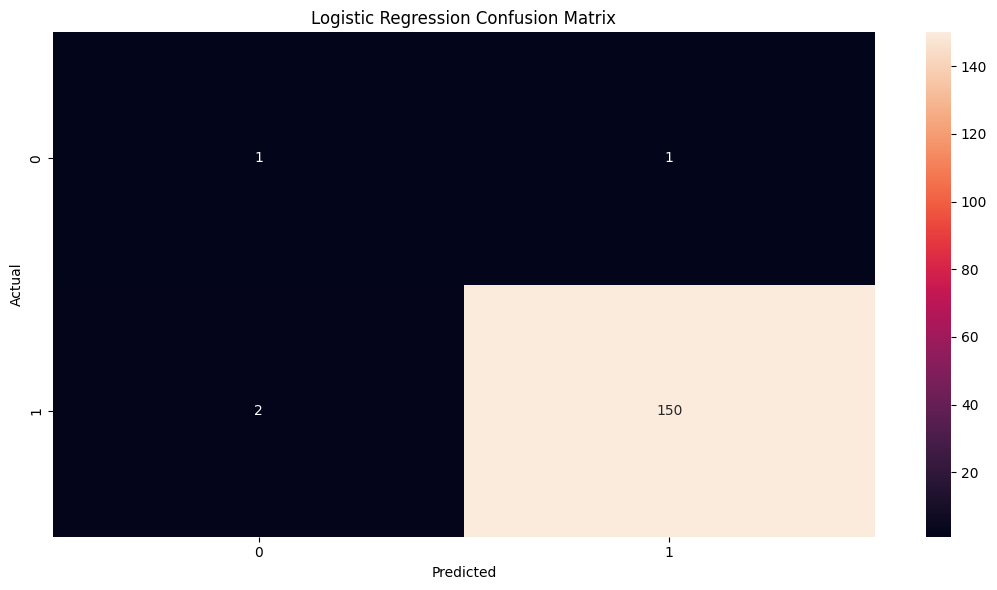

In [11]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
data = pd.read_csv('diabetes.csv', header=None, names=col_names)
print("Shape:", data.shape)
print(data.head())
print("Null values:\n", data.isnull().sum())

feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']
x = data[feature_cols]
y = data['label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

model = LogisticRegression(solver='lbfgs', max_iter=1000)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', conf_mat)
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('Accuracy in Percentage :', int(accuracy * 100), '%')

conf_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_df, annot=True, fmt='d')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

## 3. Decision Tree Classifier

Shape: (768, 9)
   pregnant  glucose   bp  skin  insulin   bmi  pedigree  age  label
0         0       84  109    36      698  55.3     1.732   53      1
1         4       54   70    64      572  23.2     1.536   41      0
2         9      194   57    37      153  43.3     2.397   77      1
3         6       44   88    70      259  43.1     0.808   59      1
4         8       89   78    25      674  36.3     0.874   43      1
Null values:
 pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64
(614, 7) (614,) (154, 7) (154,)
y_pred: [1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1]
Confusion Matrix:
 [[  1   1]
 [  3 149]]
Accuracy Score : 0.97

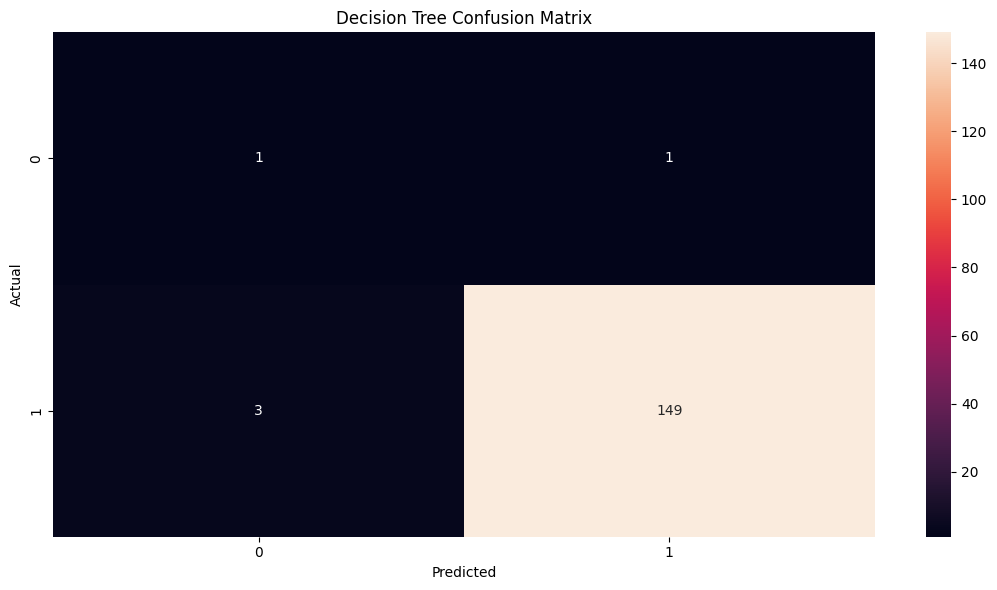

In [12]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics
import seaborn as sn
import matplotlib.pyplot as plt

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
data = pd.read_csv('diabetes.csv', header=None, names=col_names)
print("Shape:", data.shape)
print(data.head())
print("Null values:\n", data.isnull().sum())

feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']
x = data[feature_cols]
y = data['label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=5)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

model = DecisionTreeClassifier(criterion='entropy', random_state=5)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)
print('y_pred:', y_pred)

conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', conf_mat)
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('Accuracy in Percentage :', int(accuracy * 100), '%')

conf_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_df, annot=True, fmt='d')
plt.title('Decision Tree Confusion Matrix')
plt.tight_layout()
plt.show()

## 4. SVM (Support Vector Machine)

Shape: (768, 9)
   pregnant  glucose   bp  skin  insulin   bmi  pedigree  age  label
0         0       84  109    36      698  55.3     1.732   53      1
1         4       54   70    64      572  23.2     1.536   41      0
2         9      194   57    37      153  43.3     2.397   77      1
3         6       44   88    70      259  43.1     0.808   59      1
4         8       89   78    25      674  36.3     0.874   43      1
Null values:
 pregnant    0
glucose     0
bp          0
skin        0
insulin     0
bmi         0
pedigree    0
age         0
label       0
dtype: int64
(537, 7) (537,) (231, 7) (231,)
SVC [kernel - rbf]
Confusion Matrix:
 [[  0   5]
 [  0 226]]
Accuracy Score : 0.9783549783549783
Accuracy in Percentage : 97 %
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         5
           1       0.98      1.00      0.99       226

    accuracy                           0.98       231
   macro avg       0.49      0.50      0

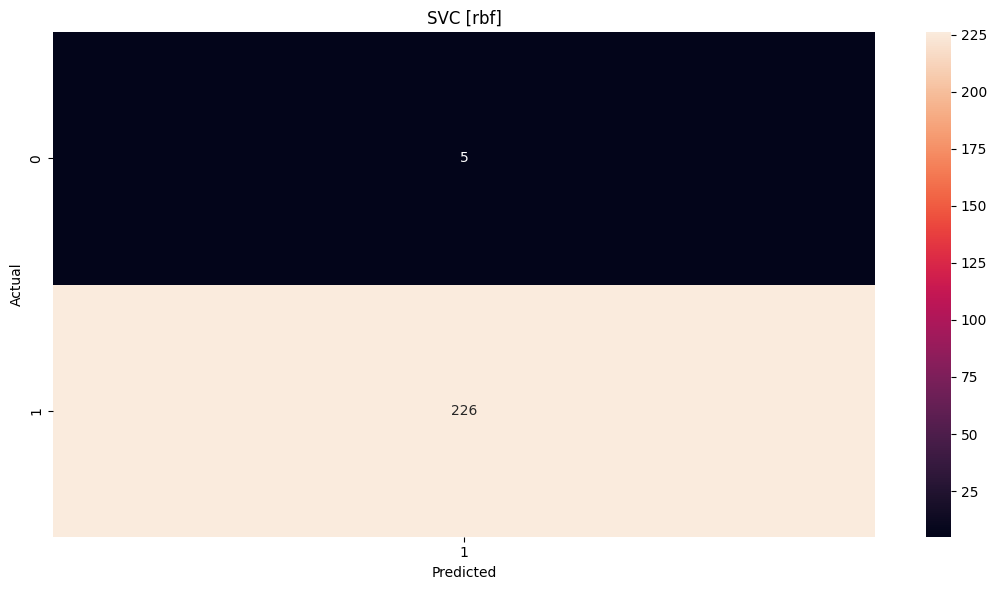

SVC [kernel - linear]
Confusion Matrix:
 [[  3   2]
 [  2 224]]
Accuracy Score : 0.9826839826839827
Accuracy in Percentage : 98 %
              precision    recall  f1-score   support

           0       0.60      0.60      0.60         5
           1       0.99      0.99      0.99       226

    accuracy                           0.98       231
   macro avg       0.80      0.80      0.80       231
weighted avg       0.98      0.98      0.98       231



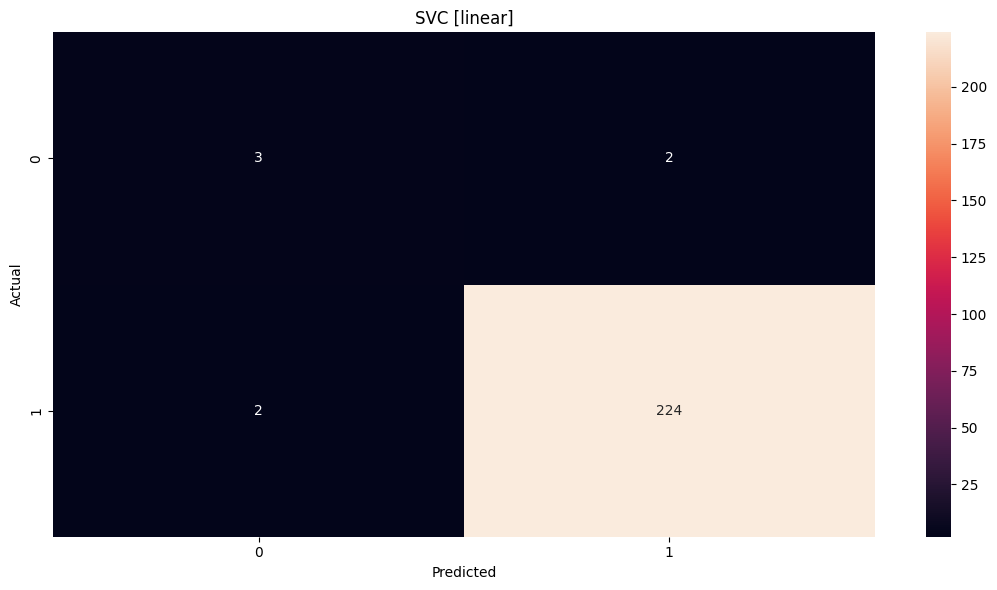

In [13]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import seaborn as sn
import matplotlib.pyplot as plt

col_names = ['pregnant', 'glucose', 'bp', 'skin', 'insulin', 'bmi', 'pedigree', 'age', 'label']
data = pd.read_csv('diabetes.csv', header=None, names=col_names)
print("Shape:", data.shape)
print(data.head())
print("Null values:\n", data.isnull().sum())

feature_cols = ['pregnant', 'insulin', 'bmi', 'age', 'glucose', 'bp', 'pedigree']
x = data[feature_cols]
y = data['label']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=5)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test  = sc.transform(x_test)

# RBF kernel
model_rbf = SVC(kernel='rbf', random_state=0)
model_rbf.fit(x_train, y_train)
svc_pred_rbf = model_rbf.predict(x_test)

conf_mat = metrics.confusion_matrix(y_test, svc_pred_rbf)
print('SVC [kernel - rbf]')
print('Confusion Matrix:\n', conf_mat)
accuracy = metrics.accuracy_score(y_test, svc_pred_rbf)
print('Accuracy Score :', accuracy)
print('Accuracy in Percentage :', int(accuracy * 100), '%')
print(classification_report(y_test, svc_pred_rbf))

conf_df = pd.crosstab(y_test, svc_pred_rbf, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_df, annot=True, fmt='d')
plt.title('SVC [rbf]')
plt.tight_layout()
plt.show()

# Linear kernel
model_lin = SVC(kernel='linear', random_state=0)
model_lin.fit(x_train, y_train)
svc_pred_lin = model_lin.predict(x_test)

conf_mat = metrics.confusion_matrix(y_test, svc_pred_lin)
print('SVC [kernel - linear]')
print('Confusion Matrix:\n', conf_mat)
accuracy = metrics.accuracy_score(y_test, svc_pred_lin)
print('Accuracy Score :', accuracy)
print('Accuracy in Percentage :', int(accuracy * 100), '%')
print(classification_report(y_test, svc_pred_lin))

conf_df = pd.crosstab(y_test, svc_pred_lin, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_df, annot=True, fmt='d')
plt.title('SVC [linear]')
plt.tight_layout()
plt.show()

## 5. K-Nearest Neighbors (KNN)

Shape: (569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area 

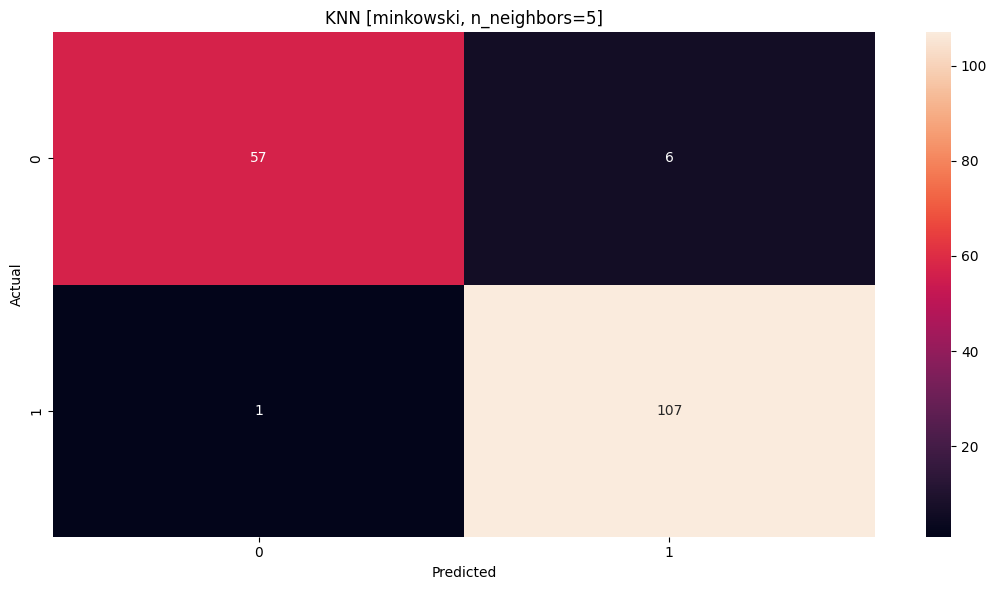

 n_neighbors  Accuracy Score
           5        0.959064
           4        0.959064
           1        0.935673
           3        0.935673
           2        0.912281


In [14]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn.preprocessing import StandardScaler
import seaborn as sn
import matplotlib.pyplot as plt

data = pd.read_csv('breast-cancer.csv')
print("Shape:", data.shape)
print(data.head())
print("Null values:\n", data.isnull().sum())

x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)
print(x_train.shape, y_train.shape, x_test.shape, y_test.shape)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test  = sc.transform(x_test)

results = []
for i in [1, 2, 3, 4, 5]:
    knn = KNeighborsClassifier(n_neighbors=i, metric='minkowski', p=2)
    knn.fit(x_train, y_train)
    y_pred_i = knn.predict(x_test)
    results.append(metrics.accuracy_score(y_test, y_pred_i))

# Final model with n=5
model = KNeighborsClassifier(n_neighbors=5, metric='minkowski', p=2)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('KNN [minkowski] — n_neighbors=5')
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', conf_mat)
accuracy = metrics.accuracy_score(y_test, y_pred)
print('Accuracy Score :', accuracy)
print('Accuracy in Percentage :', int(accuracy * 100), '%')
print(classification_report(y_test, y_pred))
print("Results for n=1..5:", results)

conf_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_df, annot=True, fmt='d')
plt.title('KNN [minkowski, n_neighbors=5]')
plt.tight_layout()
plt.show()

models_df = pd.DataFrame({'n_neighbors': [1, 2, 3, 4, 5], 'Accuracy Score': results})
print(models_df.sort_values(by='Accuracy Score', ascending=False).to_string(index=False))

## 6. K-Means Clustering

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1  Female   23                  78                      38
1           2  Female   19                 116                      88
2           3  Female   35                  59                      18
3           4  Female   40                 120                      27
4           5  Female   19                  96                      41
Shape: (200, 5)


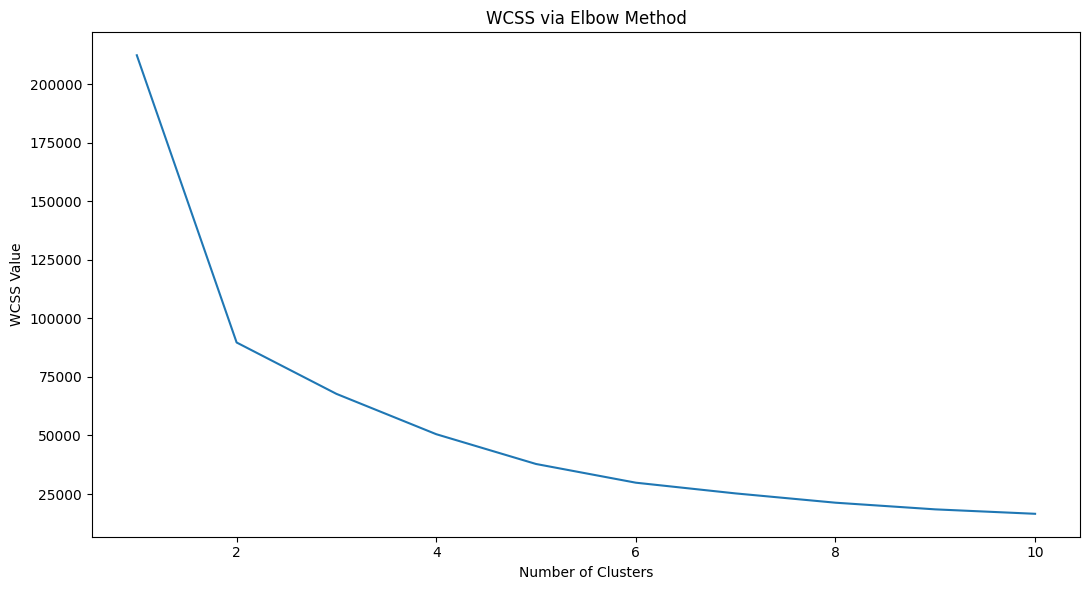

y_means:
 [2 1 3 3 2 2 1 1 3 1 3 0 2 2 3 3 3 0 0 1 0 0 2 0 2 1 2 1 0 1 3 2 3 1 0 3 3
 3 1 0 2 3 0 3 2 2 0 2 3 2 1 1 2 3 2 3 1 2 2 3 1 1 1 0 1 3 2 0 3 2 2 1 2 0
 1 0 3 2 0 3 0 3 2 1 0 0 1 2 2 1 0 1 3 3 1 2 2 3 0 3 2 1 0 0 1 0 1 1 0 0 2
 1 3 1 3 3 2 2 0 0 0 0 3 1 1 2 2 1 1 0 2 3 1 0 1 1 1 1 1 3 0 0 1 0 0 1 2 0
 0 1 3 3 1 3 3 2 3 2 2 1 1 3 1 0 3 0 3 3 0 1 2 1 1 3 0 3 3 3 0 2 3 2 2 1 1
 3 1 3 1 0 0 0 3 2 1 3 2 1 0 1]


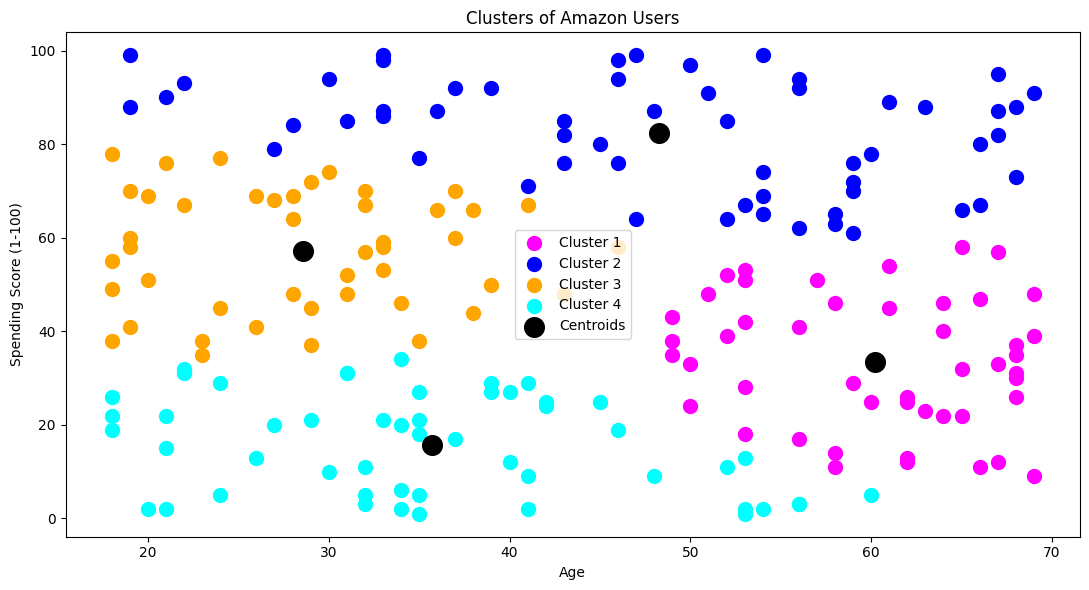

In [15]:
import pandas as pd
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

data = pd.read_csv('Amazon.com cluster model.csv')
print(data.head())
print("Shape:", data.shape)

# Columns index 2=Age, 4=Spending Score
x = data.iloc[:, [2, 4]].values

wcss = []
for i in range(1, 11):
    model = KMeans(n_clusters=i, init='k-means++', random_state=21, n_init=10)
    model.fit(x)
    wcss.append(model.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('WCSS via Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS Value')
plt.tight_layout()
plt.show()

model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
y_means = model.fit_predict(x)
print("y_means:\n", y_means)

plt.scatter(x[y_means == 0, 0], x[y_means == 0, 1], s=100, c='magenta', label='Cluster 1')
plt.scatter(x[y_means == 1, 0], x[y_means == 1, 1], s=100, c='blue',    label='Cluster 2')
plt.scatter(x[y_means == 2, 0], x[y_means == 2, 1], s=100, c='orange',  label='Cluster 3')
plt.scatter(x[y_means == 3, 0], x[y_means == 3, 1], s=100, c='cyan',    label='Cluster 4')
plt.scatter(model.cluster_centers_[:, 0], model.cluster_centers_[:, 1],
            s=200, c='black', label='Centroids')
plt.title('Clusters of Amazon Users')
plt.xlabel('Age')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Principal Component Analysis (PCA)

Target names : ['malignant' 'benign']
Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
PCA shape: (569, 3)


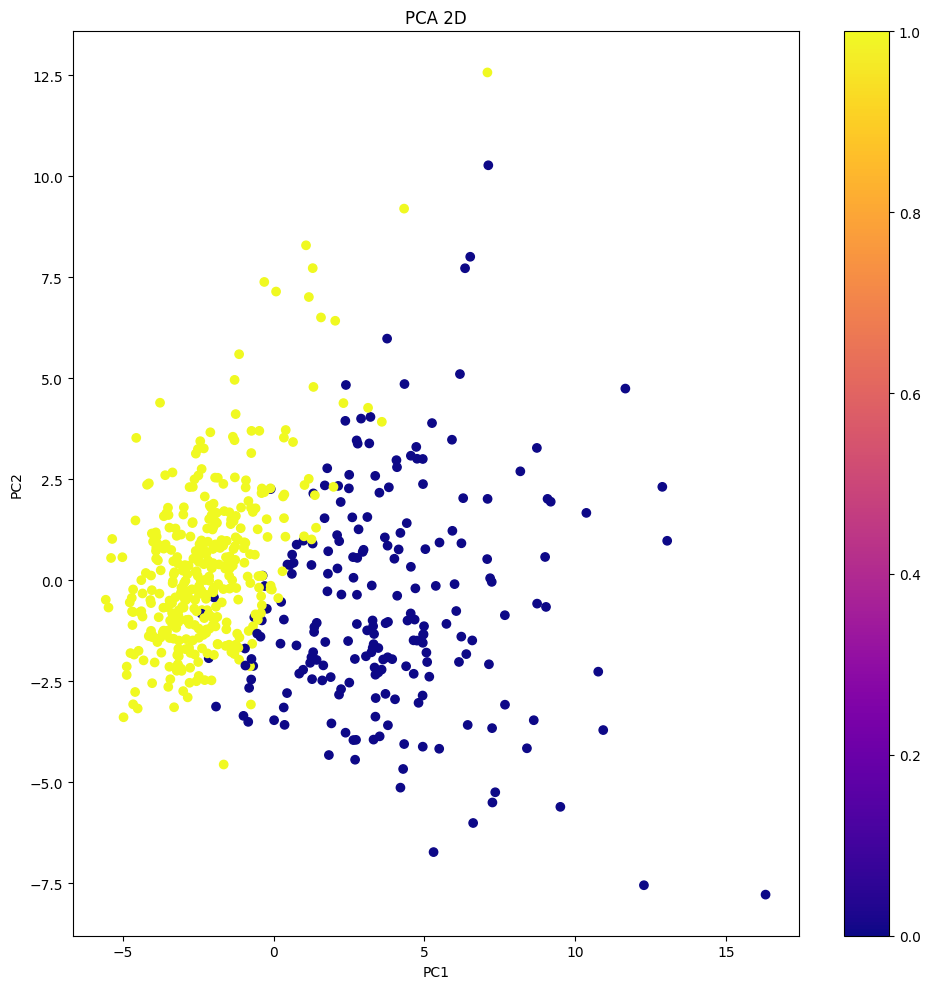

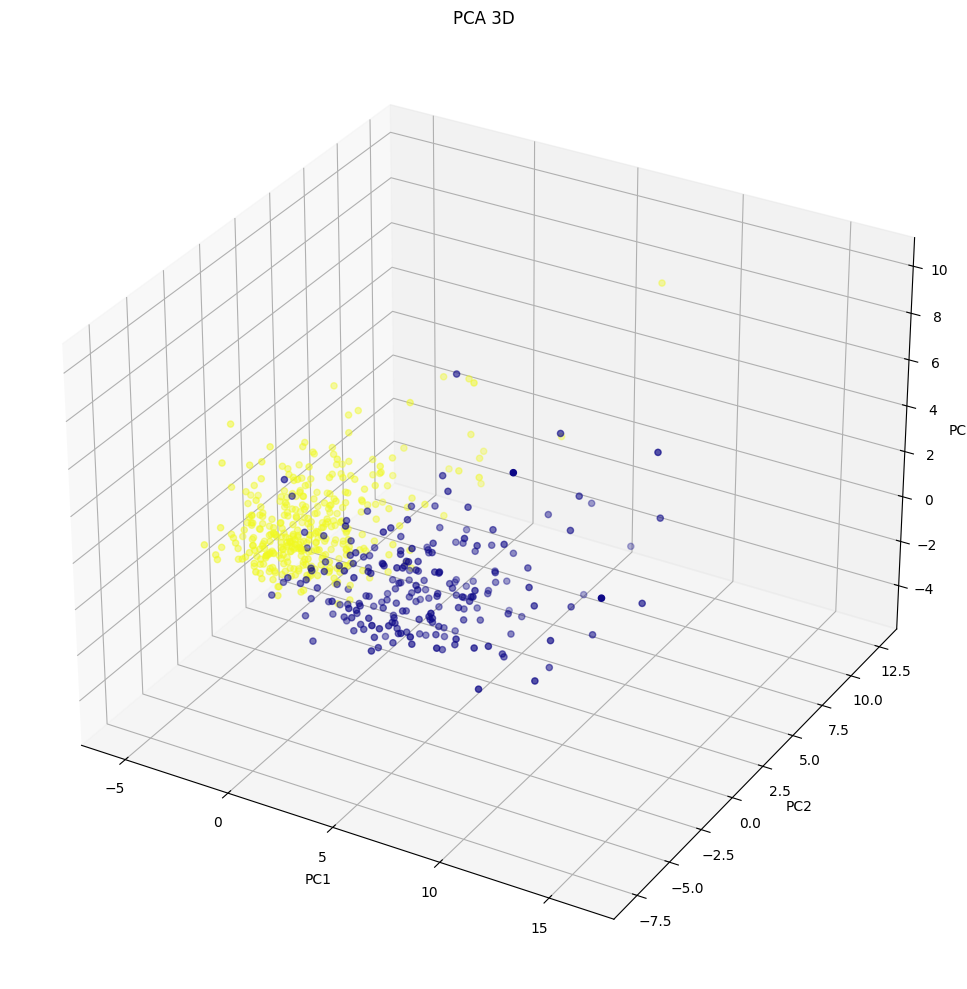

Explained Variance Ratio: [0.44272026 0.18971182 0.09393163]


In [7]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.datasets import load_breast_cancer
from mpl_toolkits.mplot3d import Axes3D

data = load_breast_cancer()
print("Target names :", data['target_names'])
print("Feature names:", data['feature_names'])

df1 = pd.DataFrame(data['data'], columns=data['feature_names'])

sc = StandardScaler()
sc.fit(df1)
scaled_data = sc.transform(df1)

principal = PCA(n_components=3)
principal.fit(scaled_data)
x = principal.transform(scaled_data)
print("PCA shape:", x.shape)

# 2D plot
plt.figure(figsize=(10, 10))
plt.title('PCA 2D')
plt.scatter(x[:, 0], x[:, 1], c=data['target'], cmap='plasma')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.colorbar()
plt.tight_layout()
plt.show()

# 3D plot
fig = plt.figure(figsize=(10, 10))
axis = fig.add_subplot(111, projection='3d')
axis.scatter(x[:, 0], x[:, 1], x[:, 2], c=data['target'], cmap='plasma')
axis.set_xlabel('PC1', fontsize=10)
axis.set_ylabel('PC2', fontsize=10)
axis.set_zlabel('PC3', fontsize=10)
plt.title('PCA 3D')
plt.tight_layout()
plt.show()

print("Explained Variance Ratio:", principal.explained_variance_ratio_)

## 8. Random Forest Classifier

Shape: (569, 31)
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area 

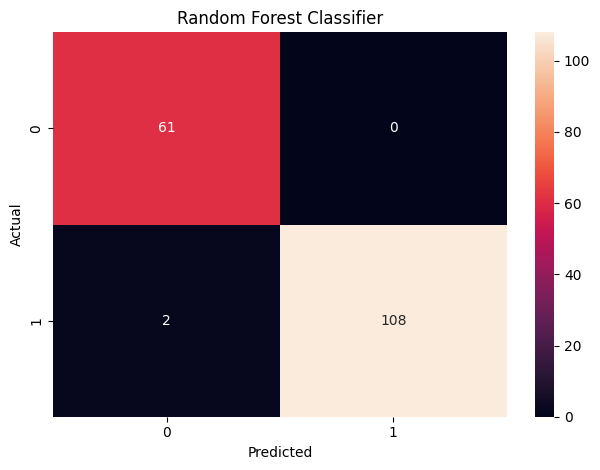


First Decision Tree Rules (first 50 lines):
|--- mean concavity <= -0.23
|   |--- mean perimeter <= 0.16
|   |   |--- compactness error <= -0.74
|   |   |   |--- worst concave points <= 0.04
|   |   |   |   |--- perimeter error <= 0.43
|   |   |   |   |   |--- worst concavity <= -0.31
|   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |--- worst concavity >  -0.31
|   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |--- perimeter error >  0.43
|   |   |   |   |   |--- class: 0.0
|   |   |   |--- worst concave points >  0.04
|   |   |   |   |--- class: 0.0
|   |   |--- compactness error >  -0.74
|   |   |   |--- class: 1.0
|   |--- mean perimeter >  0.16
|   |   |--- concavity error <= -0.39
|   |   |   |--- mean texture <= 0.08
|   |   |   |   |--- class: 1.0
|   |   |   |--- mean texture >  0.08
|   |   |   |   |--- class: 0.0
|   |   |--- concavity error >  -0.39
|   |   |   |--- class: 1.0
|--- mean concavity >  -0.23
|   |--- mean area <= 0.16
|   |   |--- worst textu

In [8]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report
import seaborn as sn
import matplotlib.pyplot as plt

data = pd.read_csv('breast-cancer.csv')
print("Shape:", data.shape)
print(data.head())

x = data.iloc[:, :-1].values
y = data.iloc[:, -1].values

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=41)

sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test  = sc.transform(x_test)

model = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

print('Random Forest Classifier')
conf_mat = metrics.confusion_matrix(y_test, y_pred)
print('Confusion Matrix:\n', conf_mat)
acc = accuracy_score(y_test, y_pred)
print('Accuracy Score :', acc)
print('Accuracy in Percentage :', int(acc * 100), '%')
print(classification_report(y_test, y_pred))

conf_df = pd.crosstab(y_test, y_pred, rownames=['Actual'], colnames=['Predicted'])
sn.heatmap(conf_df, annot=True, fmt='d')
plt.title('Random Forest Classifier')
plt.tight_layout()
plt.show()

# Decision tree visualization using text (avoids pydotplus dependency)
from sklearn.tree import export_text
feature_names = list(data.columns[:-1])
tree_rules = export_text(model.estimators_[0], feature_names=feature_names)
print("\nFirst Decision Tree Rules (first 50 lines):")
print('\n'.join(tree_rules.split('\n')[:50]))

## 9. Time Series Modeling

            S4248SM144NCEN
DATE                      
2016-08-01            8041
2016-09-01            7874
2016-10-01            7982
2016-11-01            8730
2016-12-01            8994
            S4248SM144NCEN  Sale_LastMonth  Sale_2Monthsback  Sale_3Monthsback
DATE                                                                          
1992-04-01            4410          3951.0            3511.0            2892.0
1992-05-01            3899          4410.0            3951.0            3511.0
1992-06-01            3559          3899.0            4410.0            3951.0
1992-07-01            3330          3559.0            3899.0            4410.0
1992-08-01            2554          3330.0            3559.0            3899.0


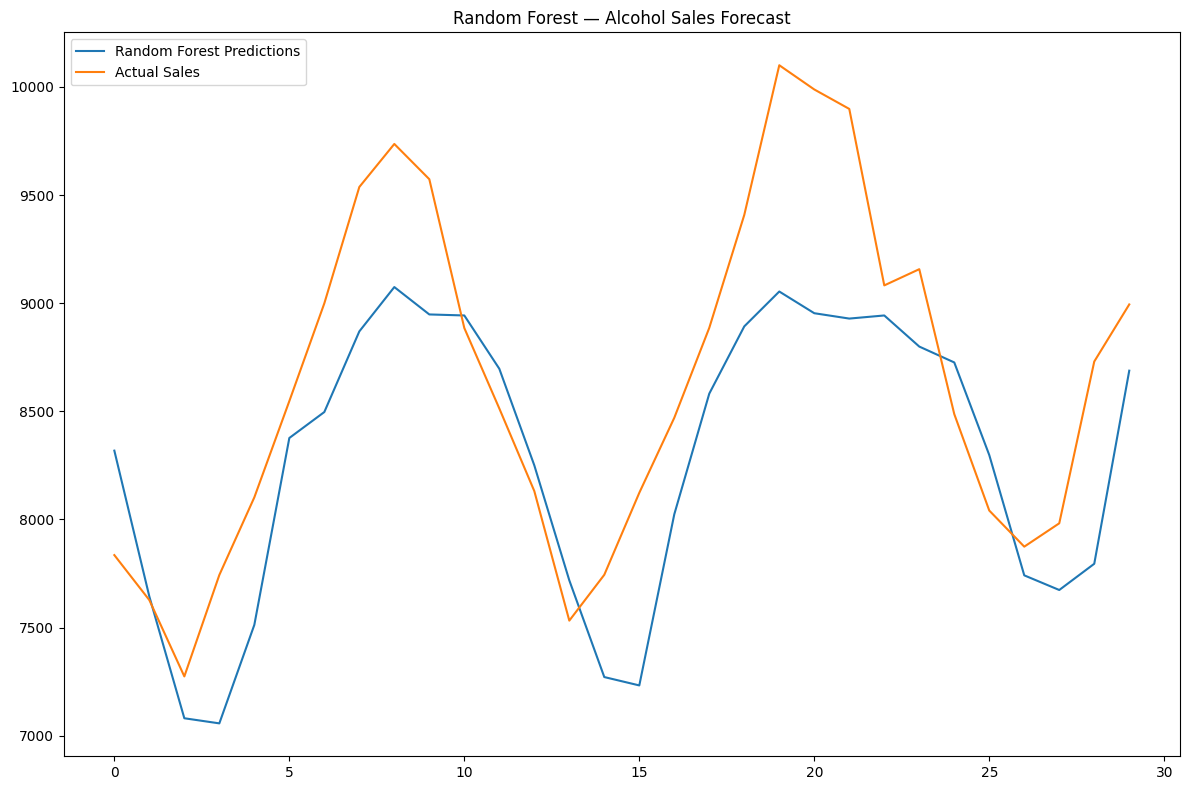

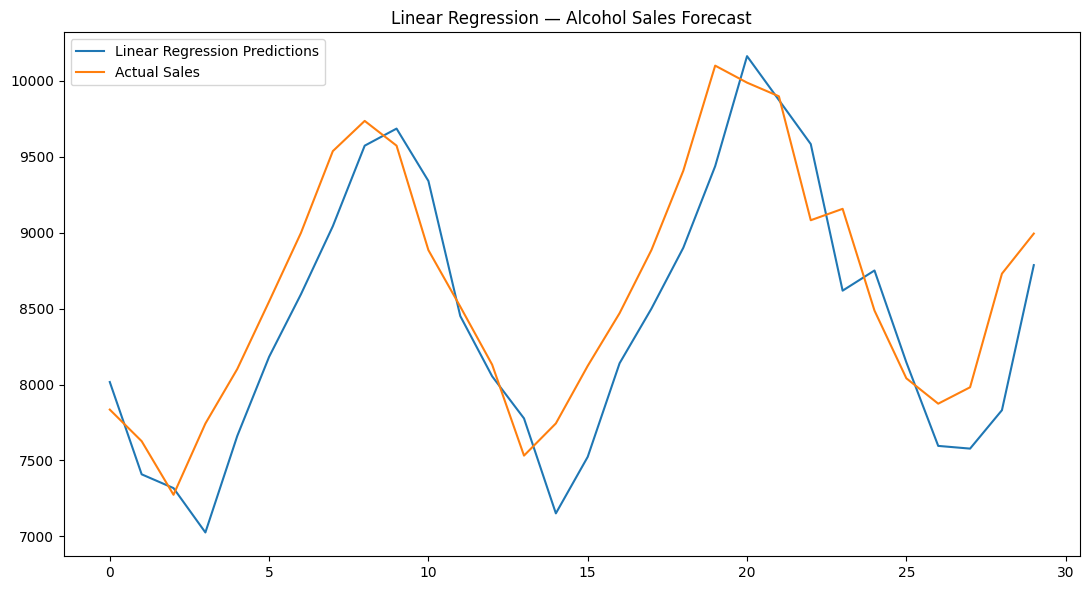

RMSE for Random Forest    : 540.42
RMSE for Linear Regression: 410.52


In [9]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
import numpy as np
from sklearn.metrics import mean_squared_error
from math import sqrt
import matplotlib.pyplot as plt

df = pd.read_csv('Alcohol_Sales.csv', index_col='DATE', parse_dates=True)
df.index.freq = 'MS'
print(df.tail())

# Fix typo: 'coulmns' -> correct column reference
col = df.columns[0]   # 'S4248SM144NCEN'
df['Sale_LastMonth']   = df[col].shift(1)
df['Sale_2Monthsback'] = df[col].shift(2)
df['Sale_3Monthsback'] = df[col].shift(3)

df = df.dropna()
print(df.head())

lin_model = LinearRegression()
rf_model  = RandomForestRegressor(n_estimators=100, max_features=3, random_state=1)

x1 = np.array(df['Sale_LastMonth']).reshape(-1, 1)
x2 = np.array(df['Sale_2Monthsback']).reshape(-1, 1)
x3 = np.array(df['Sale_3Monthsback']).reshape(-1, 1)
y  = np.array(df[col]).reshape(-1, 1)
final_x = np.concatenate((x1, x2, x3), axis=1)

# Fix slice: use [-30:] for test set (last 30 rows)
X_train, X_test = final_x[:-30], final_x[-30:]
y_train, y_test = y[:-30], y[-30:]

rf_model.fit(X_train, y_train.ravel())
lin_model.fit(X_train, y_train.ravel())

pred     = rf_model.predict(X_test)
lin_pred = lin_model.predict(X_test)

plt.rcParams['figure.figsize'] = (12, 8)
plt.plot(pred,   label='Random Forest Predictions')
plt.plot(y_test, label='Actual Sales')
plt.legend(loc='upper left')
plt.title('Random Forest — Alcohol Sales Forecast')
plt.tight_layout()
plt.show()

plt.rcParams['figure.figsize'] = (11, 6)
plt.plot(lin_pred, label='Linear Regression Predictions')
plt.plot(y_test,   label='Actual Sales')
plt.legend(loc='upper left')
plt.title('Linear Regression — Alcohol Sales Forecast')
plt.tight_layout()
plt.show()

rmse_rf = sqrt(mean_squared_error(pred,     y_test))
rmse_lr = sqrt(mean_squared_error(lin_pred, y_test))
print('RMSE for Random Forest    :', round(rmse_rf, 2))
print('RMSE for Linear Regression:', round(rmse_lr, 2))